In [ ]:
!pip install psaw praw langdetect pmaw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 16.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=2a1e579230c13b339df223118d7cf3f8e8d13642107cb28cc3a37fb5798c4eaf
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [ ]:
import pandas as pd
import datetime as dt
import langdetect
from pmaw import PushshiftAPI
import praw

# ---- CONFIG ----
SUBREDDITS = ["adhd", "adhdwomen", "mentalhealth", "malementalhealth"]
START_DATE = int(dt.datetime(2021, 1, 1).timestamp())
END_DATE = int(dt.datetime(2025, 12, 31).timestamp())
MIN_WORDS = 50
TARGET_POSTS = 5000   # per subreddit (approx)

# ---- PMAW Setup (for historical) ----
ps_api = PushshiftAPI(num_workers=10, rate_limit=60)

# ---- PRAW Setup (for recent / fallback) ----
reddit = praw.Reddit(
    client_id='YetFLz20wt1E6AmxeKZp9A',
    client_secret='W89zVKqYqr1LHfFe4pYfR9_zggowHQ',
    user_agent='windows:sexualassault.disclosure.bot:v0.1 (by u/Affectionate-Turn393)')


# ---- Helpers ----
def is_english(text):
    try:
        return langdetect.detect(text) == "en"
    except:
        return False

def clean_post(post_dict):
    """Standardize fields between PMAW + PRAW"""
    return {
        "subreddit": post_dict.get("subreddit"),
        "title": post_dict.get("title"),
        "body": post_dict.get("selftext") or "",
        "created_utc": post_dict.get("created_utc"),
        "date": dt.datetime.fromtimestamp(post_dict.get("created_utc")),
        "upvotes": post_dict.get("score"),
        "num_comments": post_dict.get("num_comments"),
        "author": str(post_dict.get("author")),
        "flair": post_dict.get("link_flair_text"),
    }

# ---- Fetch with PMAW ----
def fetch_pmaw(subreddit, max_posts=5000):
    print(f"[PMAW] Fetching r/{subreddit}...")
    results = ps_api.search_submissions(
        subreddit=subreddit,
        after=START_DATE,
        before=END_DATE,
        limit=max_posts
    )
    posts = []
    for post in results:
        text = (post.get("title") or "") + " " + (post.get("selftext") or "")
        if len(text.split()) >= MIN_WORDS and is_english(text):
            posts.append(clean_post(post))
        if len(posts) >= max_posts:
            break
    return posts

# ---- Fetch with PRAW (for recent posts / fallback) ----
def fetch_praw(subreddit, max_posts=1000):
    print(f"[PRAW] Fetching r/{subreddit} recent...")
    posts = []
    for submission in reddit.subreddit(subreddit).new(limit=max_posts):
        text = (submission.title or "") + " " + (submission.selftext or "")
        if len(text.split()) >= MIN_WORDS and is_english(text):
            post_dict = {
                "subreddit": subreddit,
                "title": submission.title,
                "selftext": submission.selftext,
                "created_utc": int(submission.created_utc),
                "score": submission.score,
                "num_comments": submission.num_comments,
                "author": str(submission.author),
                "link_flair_text": submission.link_flair_text,
            }
            posts.append(clean_post(post_dict))
    return posts

# ---- MAIN ----
all_posts = []
for sub in SUBREDDITS:
    # Try historical first
    pmaw_posts = fetch_pmaw(sub, TARGET_POSTS)
    all_posts.extend(pmaw_posts)

    # Add a smaller batch of recent posts
    praw_posts = fetch_praw(sub, 500)  # adjust if needed
    all_posts.extend(praw_posts)

# ---- Save ----
df = pd.DataFrame(all_posts)
df.drop_duplicates(subset=["title", "body"], inplace=True)  # remove overlaps
df.to_csv("reddit_mentalhealth_dataset.csv", index=False)

print(f"Done! Saved {len(df)} posts to reddit_mentalhealth_dataset.csv")


[PMAW] Fetching r/adhd...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



[PRAW] Fetching r/adhd recent...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



[PMAW] Fetching r/adhdwomen...


...

[PMAW] Fetching r/malementalhealth...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



[PRAW] Fetching r/malementalhealth recent...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Done! Saved 1787 posts to reddit_mentalhealth_dataset.csv


In [ ]:
from google.colab import files
files.download("reddit_mentalhealth_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The error message `ModuleNotFoundError: No module named 'psaw'` indicates that the `psaw` library was not found when the code was executed. To fix this, you need to install the library using pip. The cell above installs `psaw`, `praw`, and `langdetect`, which are all imported in your code.

In [ ]:
import pandas as pd
import spacy

# Load dataset generated in the previous step
df = pd.read_csv("reddit_mentalhealth_dataset.csv")

# Create 'clean_text' by combining 'title' and 'body'
# This assumes 'clean_text' was intended to be the primary text for processing
df["clean_text"] = df["title"].fillna("") + " " + df["body"].fillna("")
df["clean_text"] = df["clean_text"].str.strip() # Remove leading/trailing spaces


# Load spaCy English model
# Check if the model is downloaded, if not, download it.
try:
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# we just need tokenizer + lemmatizer

# Define stopwords but keep important ones
custom_keep_words = {"man", "woman", "men", "women", "diagnosis", "adhd", "therapy", "therapist"}
stopwords = nlp.Defaults.stop_words - custom_keep_words

def preprocess_spacy(text):
    doc = nlp(text)
    tokens = []
    for token in doc:
        # keep only alphabetic words
        if token.is_alpha:
            # skip stopwords
            if token.lemma_.lower() not in stopwords:
                tokens.append(token.lemma_.lower())
    return " ".join(tokens)

# Apply spaCy preprocessing
df["processed_text"] = df["clean_text"].astype(str).apply(preprocess_spacy)

# Save final preprocessed dataset
df.to_csv("reddit_mentalhealth_preprocessed.csv", index=False)

print("✅ Step 2 & 3 done. Saved as reddit_mentalhealth_preprocessed.csv")

✅ Step 2 & 3 done. Saved as reddit_mentalhealth_preprocessed.csv


In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Load preprocessed dataset
df = pd.read_csv("reddit_mentalhealth_preprocessed.csv")

# Group by subreddit (we’ll run separately for each subreddit)
for sub in df["subreddit"].unique():
    print(f"\n=== Running BERTopic for r/{sub} ===")
    sub_df = df[df["subreddit"] == sub].copy() # Use .copy() to avoid SettingWithCopyWarning

    # Ensure processed_text is string and handle potential NaNs
    sub_df["processed_text"] = sub_df["processed_text"].astype(str).fillna("")

    # Initialize BERTopic with a vectorizer (remove very rare/common words)
    vectorizer_model = CountVectorizer(ngram_range=(1,2), stop_words="english", min_df=2) # Reduced min_df
    topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english")

    topics, probs = topic_model.fit_transform(sub_df["processed_text"].tolist())

    # Save topic assignments
    sub_df["topic"] = topics
    sub_df.to_csv(f"topics_bertopic_{sub}.csv", index=False)

    # Print summary
    print(topic_model.get_topic_info().head(10))
    topic_model.visualize_barchart(top_n_topics=10).show()


=== Running BERTopic for r/adhd ===


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

   Topic  Count                       Name  \
0     -1    208     -1_like_feel_know_want   
1      0     90      0_feel_like_want_life   
2      1     64  1_feel_like_feel like_bad   
3      2     39      2_feel_like_know_want   
4      3     30    3_help_need_parent_tell   

                                      Representation  \
0  [like, feel, know, want, think, life, time, pe...   
1  [feel, like, want, life, people, friend, know,...   
2  [feel, like, feel like, bad, day, know, try, s...   
3  [feel, like, know, want, people, life, year, t...   
4  [help, need, parent, tell, mental, health, app...   

                                 Representative_Docs  
0  [scared misdiagnosis hi advice amazing appreci...  
1  [want kill people scared act day want kill peo...  
2  [word type avoidance motivation hard describe ...  
3  [year year end thing know start year insanely ...  
4  [m feel extremely anxious newly prescribe medi...  



=== Running BERTopic for r/malementalhealth ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Topic  Count                                Name  \
0     -1    136        -1_like_feel_thing_feel like   
1      0     53          0_feel_like_feel like_time   
2      1     50  1_mental_health_mental health_help   
3      2     49               2_man_woman_like_feel   
4      3     47             3_day_bipolar_feel_like   
5      4     44               4_feel_like_life_year   
6      5     16      5_sexual_urge_sex_masturbation   
7      6     12       6_trauma_heal_emotion_process   

                                      Representation  \
0  [like, feel, thing, feel like, time, want, lif...   
1  [feel, like, feel like, time, thing, think, fe...   
2  [mental, health, mental health, help, man, wan...   
3  [man, woman, like, feel, girl, want, look, peo...   
4  [day, bipolar, feel, like, time, know, want, w...   
5  [feel, like, life, year, know, feel like, job,...   
6  [sexual, urge, sex, masturbation, life, porn, ...   
7  [trauma, heal, emotion, process, heal trauma, ...   


In [ ]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# Load preprocessed dataset
df = pd.read_csv("reddit_mentalhealth_preprocessed.csv")

# Define custom stopwords
custom_stopwords = {"feel", "like", "people", "really", "think", "know", "want", "lot", "one", "something"}

# Combine sklearn default + custom
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords)) # Convert frozenset to list

# Group by subreddit
for sub in df["subreddit"].unique():
    print(f"\n=== Running BERTopic for r/{sub} ===")
    sub_df = df[df["subreddit"] == sub].copy()
    sub_df["processed_text"] = sub_df["processed_text"].astype(str).fillna("")

    # Vectorizer with updated stopwords
    vectorizer_model = CountVectorizer(
        ngram_range=(1,2),
        stop_words=stop_words,
        min_df=2
    )

    topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english")

    topics, probs = topic_model.fit_transform(sub_df["processed_text"].tolist())

    # Save topic assignments
    sub_df["topic"] = topics
    sub_df.to_csv(f"topics_bertopic_{sub}.csv", index=False)

    # Print summary
    print(topic_model.get_topic_info().head(10))
    topic_model.visualize_barchart(top_n_topics=10).show()


=== Running BERTopic for r/adhd ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Topic  Count                     Name  \
0     -1     55  -1_adhd_tooth_use_sleep   
1      0    319       0_adhd_mg_work_day   
2      1    122    1_work_time_thing_try   

                                      Representation  \
0  [adhd, tooth, use, sleep, help, try, time, nee...   
1  [adhd, mg, work, day, time, med, medication, s...   
2  [work, time, thing, try, day, help, start, nee...   

                                 Representative_Docs  
0  [nail biting ritalin hi good people adhd reddi...  
1  [wonder s experience adhd like absent minded f...  
2  [juggle time job school social life alive heal...  



=== Running BERTopic for r/adhdwomen ===


...

   Topic  Count                      Name  \
0     -1    165   -1_time_life_year_thing   
1      0    150  0_life_friend_year_thing   
2      1     75     1_day_bad_thing_start   
3      2     41   2_need_help_parent_tell   

                                      Representation  \
0  [time, life, year, thing, way, love, good, wor...   
1  [life, friend, year, thing, time, tell, try, s...   
2  [day, bad, thing, start, anxiety, time, try, s...   
3  [need, help, parent, tell, health, mental, thi...   

                                 Representative_Docs  
0  [med therapy anxiety manage pretty therapy lat...  
1  [day agonizing lonely day hope appropriate for...  
2  [deal anxiety depersonalization normal hi rn w...  
3  [life update join reddit talk life ask advice ...  



=== Running BERTopic for r/malementalhealth ===


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Topic  Count                                Name  \
0     -1    164              -1_time_thing_life_try   
1      0     54               0_man_woman_girl_look   
2      1     48  1_mental_health_mental health_help   
3      2     45            2_bipolar_day_time_world   
4      3     32               3_life_year_job_thing   
5      4     27           4_anxiety_sleep_thing_day   
6      5     19       5_trauma_emotion_heal_process   
7      6     18      6_sexual_sex_urge_masturbation   

                                      Representation  \
0  [time, thing, life, try, year, friend, work, h...   
1  [man, woman, girl, look, relationship, guy, li...   
2  [mental, health, mental health, help, man, dep...   
3  [bipolar, day, time, world, year, friend, thin...   
4  [life, year, job, thing, wife, month, end, wor...   
5  [anxiety, sleep, thing, day, coffee, normal, c...   
6  [trauma, emotion, heal, process, thing, past, ...   
7  [sexual, sex, urge, masturbation, porn, life, ...   


In [ ]:
fig1 = topic_model.visualize_barchart(top_n_topics=10)
fig1.show()

    # 2. Topic Word Score per Topic (clickable in Plotly)
    # You can pass a topic number, e.g., topic=1
fig2 = topic_model.visualize_barchart(top_n_topics=5)
fig2.show()

    # 3. Topic Map (2D semantic map of topics)
# Check if there are enough topics to visualize a topic map
num_topics_for_map = topic_model.get_topic_info().shape[0] - 1 # Exclude noise topic (-1)
if num_topics_for_map >= 2: # UMAP usually needs at least 2 points to project
    try:
        fig3 = topic_model.visualize_topics()
        fig3.show()
    except ValueError as e:
        print(f"Could not visualize Topic Map due to an error: {e}. This might happen if topic embeddings are too similar or sparse for UMAP to generate a meaningful projection with a small number of topics.")
else:
    print(f"Skipping Topic Map visualization as only {num_topics_for_map} non-noise topics were found, which is insufficient for a meaningful 2D projection.")

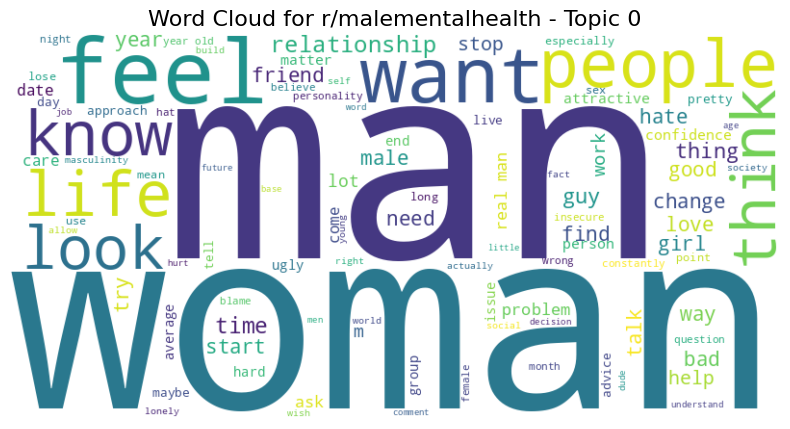

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Load the preprocessed data with topic assignments
# Assuming you have already run the BERTopic code and saved the topics_bertopic_*.csv files
# For demonstration, we'll load the data for the last processed subreddit.
# You might need to adjust the filename based on which subreddit you want to visualize.
try:
    sub_df = pd.read_csv("topics_bertopic_malementalhealth.csv") # Example: use the last processed subreddit
except FileNotFoundError:
    print("Please run the BERTopic cell first to generate the topic CSVs.")
    # Assuming df from previous cells is available if CSV not found for some reason
    # sub_df = df[df["subreddit"] == "malementalhealth"].copy()
    # sub_df["processed_text"] = sub_df["processed_text"].astype(str).fillna("")
    # topics, probs = topic_model.fit_transform(sub_df["processed_text"].tolist())
    # sub_df["topic"] = topics


# Select a specific topic to visualize (e.g., Topic 0)
topic_to_visualize = 0 # Change this to the topic number you want to visualize
subreddit = "malementalhealth" # Update this if you changed the filename above

# Filter the DataFrame for the selected topic and get the processed text
topic_text = " ".join(sub_df[sub_df["topic"] == topic_to_visualize]["processed_text"].tolist())

# Generate the word cloud
wc = WordCloud(width=800, height=400, background_color="white",
                   colormap="viridis", max_words=100).generate(topic_text)

# Plot the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud for r/{subreddit} - Topic {topic_to_visualize}", fontsize=16)
plt.show()

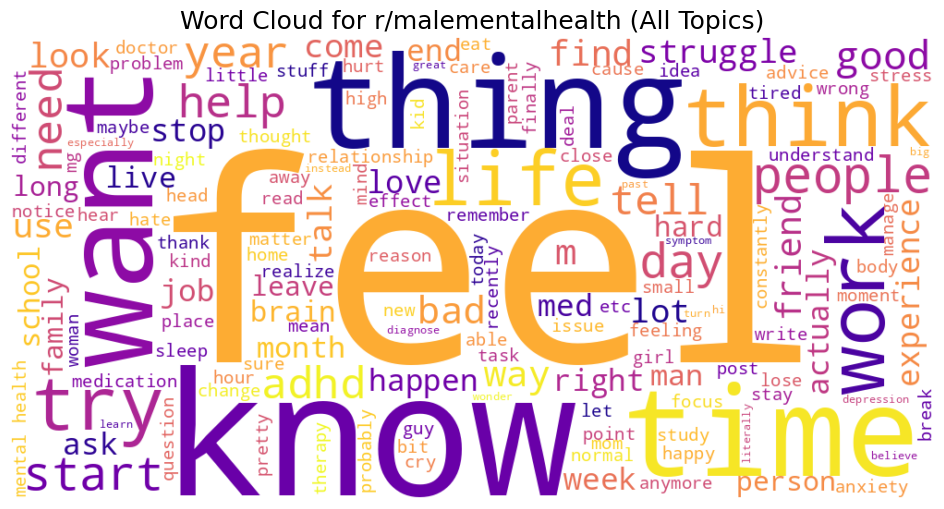

In [ ]:
# Whole subreddit cloud
all_text = " ".join(df["processed_text"].tolist())

wc = WordCloud(width=1000, height=500, background_color="white",
               colormap="plasma", max_words=150).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud for r/{subreddit} (All Topics)", fontsize=18)
plt.show()


In [ ]:
import pandas as pd
import glob

# List all generated topic files
all_topic_files = glob.glob("topics_bertopic_*.csv")

# Read and concatenate all topic files into a single DataFrame
if all_topic_files:
    df_list = [pd.read_csv(file) for file in all_topic_files]
    df = pd.concat(df_list, ignore_index=True)
    print(f"Successfully loaded and combined {len(df)} posts from {len(all_topic_files)} subreddits.")
else:
    print("No topic files found. Please ensure BERTopic processing was successful.")
    # Optionally, you might want to exit or raise an error here if df is critical
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Calculate topic frequency per subreddit
topic_counts = (
    df.groupby(['subreddit', 'topic'])
      .size()
      .reset_index(name='count')
)

# Convert to percentage
topic_counts['percentage'] = (
    topic_counts.groupby('subreddit')['count']
    .transform(lambda x: 100 * x / x.sum())
)

topic_counts.head()

Successfully loaded and combined 1787 posts from 4 subreddits.


,subreddit,topic,count,percentage
0,adhd,-1,55,11.088710
1,adhd,0,319,64.314516
2,adhd,1,122,24.596774
3,adhdwomen,-1,119,26.269316
4,adhdwomen,0,190,41.942605


In [ ]:
topic_pivot = topic_counts.pivot(
    index='topic',
    columns='subreddit',
    values='percentage'
).fillna(0)

topic_pivot

subreddit,adhd,adhdwomen,malementalhealth,mentalhealth
topic,,,,
-1,11.088710,26.269316,40.294840,38.283063
0,64.314516,41.942605,13.267813,34.802784
1,24.596774,21.412804,11.793612,17.401392
2,0.000000,10.375276,11.056511,9.512761
3,0.000000,0.000000,7.862408,0.000000
4,0.000000,0.000000,6.633907,0.000000
5,0.000000,0.000000,4.668305,0.000000
6,0.000000,0.000000,4.422604,0.000000


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['clean_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

df[['clean_text', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,clean_text,sentiment
0,Consumerism-resistant hyperfixation ideas? My ...,0.7994
1,Being diagnosed late made me angry I’m in my e...,0.9781
2,"Intuniv Update, Had To Stop Taking Immediately...",-0.3734
3,"Did I trick my psychologist, or did bad diet t...",-0.9076
4,0 days since last incident currently unmedicat...,-0.8415


In [ ]:
sentiment_by_sub = df.groupby('subreddit')['sentiment'].mean()
sentiment_by_sub

,sentiment
subreddit,
adhd,0.157312
adhdwomen,0.158665
malementalhealth,0.051245
mentalhealth,-0.165635


In [ ]:
sentiment_topic = (
    df.groupby(['subreddit', 'topic'])['sentiment']
      .mean()
      .reset_index()
)

sentiment_topic.head()

,subreddit,topic,sentiment
0,adhd,-1,0.156798
1,adhd,0,0.181634
2,adhd,1,0.093948
3,adhdwomen,-1,0.183834
4,adhdwomen,0,0.133275


In [ ]:
from scipy.stats import ttest_ind

group1 = df[df['subreddit'] == 'adhdwomen']['sentiment']
group2 = df[df['subreddit'] == 'adhd']['sentiment']

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 0.026620753030630644
P-value: 0.9787679310238667


In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['topic'], df['subreddit'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 637.0175168069866
P-value: 2.5812374148459282e-121


In [ ]:
df['created_utc'] = pd.to_datetime(df['created_utc'])
df['month'] = df['created_utc'].dt.to_period('M')

monthly_trends = (
    df.groupby(['month', 'subreddit'])
      .size()
      .reset_index(name='count')
)

monthly_trends.head()

,month,subreddit,count
0,1970-01,adhd,496
1,1970-01,adhdwomen,453
2,1970-01,malementalhealth,407
3,1970-01,mentalhealth,431


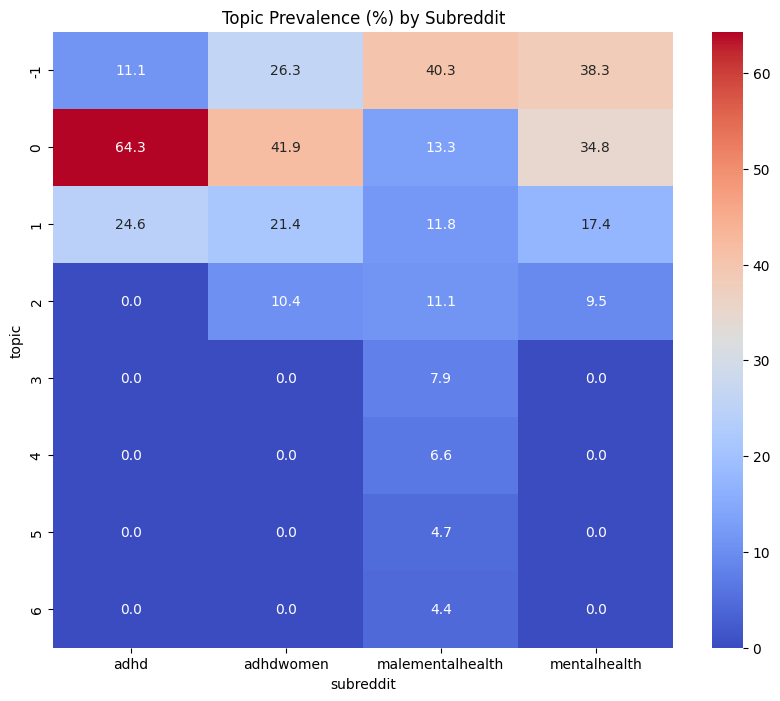

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(topic_pivot, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Topic Prevalence (%) by Subreddit")
plt.show()

In [ ]:
help_keywords = ['any advice', 'what should i do', 'help me', 'need help']

def detect_help(text):
    text = str(text).lower()
    return any(keyword in text for keyword in help_keywords)

df['help_seeking'] = df['clean_text'].apply(detect_help)

df.groupby('subreddit')['help_seeking'].mean()

,help_seeking
subreddit,
adhd,0.149194
adhdwomen,0.128035
malementalhealth,0.132678
mentalhealth,0.122970
